This notebook performs an evaluation of DMD models trained on 10 years (with a 6h time step) of T850 by comparing their reconstruction and forecasting performance as we vary different hyperparameters, namely the number of modes and the type of pre-processing (with and without time-delay embedding a.k.a. Hankel pre-processing). Reconstructions are evaluated over the last two months of training data, while forecasts are evaluated over a 45 day period. Both deterministic and probabilistic (via bootstrap aggregation) DMD models are analyzed. Model performance is compared against climatology.

In [1]:
import xarray as xr
from glob import glob
from pathlib import Path
from matplotlib import pyplot as plt
from dask.distributed import Client
import pandas as pd
from svdrom.weather_utils import (
    compute_rmse,
    expand_time_climatology,
)

## Deterministic DMD models

In [2]:
reconstruction_files = sorted(glob("metrics/deterministic/reconstruction*"))
forecast_files = sorted(glob("metrics/deterministic/forecast*"))

Create two dictionaries to store the RMSE of the DMD reconstructions: one for reconstructions without Hankel pre-processing and one for reconstructions with Hankel pre-processing. The dictionaries keys correspond to the number of modes in te DMD model, which is taken from the file name. 

In [3]:
reconstructions = {}
reconstructions_hankel = {}
for file in reconstruction_files:
    path = Path(file)
    name = path.name.split(".")[0]
    name = name.split("rmse_")[-1]
    if "hankel" in name:
        reconstructions_hankel[name] = xr.open_dataarray(file)
    else:
        reconstructions[name] = xr.open_dataarray(file)

Do the same for the RMSE of the DMD forecasts.

In [4]:
forecasts = {}
forecasts_hankel = {}
for file in forecast_files:
    path = Path(file)
    name = path.name.split(".")[0]
    name = name.split("rmse_")[-1]
    if "hankel" in name:
        forecasts_hankel[name] = xr.open_dataarray(file)
    else:
        forecasts[name] = xr.open_dataarray(file)

The RMSE of the reconstructions and forecasts are already averaged across the spatial dimension (over latitude and longitude). Here we also average them across the temporal dimension to get a single RMSE score per DMD model.

In [5]:
reconstruction_averages = []
reconstruction_hankel_averages = []
forecast_averages = []
forecast_hankel_averages = []

for key in reconstructions.keys():
    reconstruction_averages.append((key, reconstructions[key].mean().values))
    forecast_averages.append((key, forecasts[key].mean().values))

for key in reconstructions_hankel.keys():
    reconstruction_hankel_averages.append(
        (key, reconstructions_hankel[key].mean().values)
    )
    forecast_hankel_averages.append((key, forecasts_hankel[key].mean().values))

### Compute climatology RMSE

To have a baseline against which to compare the performance of the DMD models, we now compute the RMSE of climatology forecasts. Two climatologies are used here. Short-term climatology has been computed with `svdrom.weather_utils.compute_climatology()`, using the same training data used to build the DMD models (10 years: 2010-2019). Long-term climatology has been computed using 30 years (1990-2019), and has been downloaded from [WeatherBench](https://weatherbench2.readthedocs.io/en/latest/data-guide.html#era5-climatology).

To compute the RMSE of climatology, we use a local multi-threading Dask cluster.

In [6]:
client = Client(processes=False)

In [7]:
pressure_level = 850
doy_slice = slice(180, 240)  # day-of-year slice

In [8]:
ground_truth = xr.open_dataarray("input_data/era5_slice.zarr", engine="zarr")
assert ground_truth.level.values == pressure_level, (
    f"Ground truth data is not found at pressure level {pressure_level}."
)

clima_long_term = xr.open_dataarray(
    "input_data/climatology_1990-2019.zarr", engine="zarr", chunks="auto"
)
clima_long_term = clima_long_term.sel(level=pressure_level)
clima_long_term = clima_long_term.sel(dayofyear=doy_slice)
clima_long_term = expand_time_climatology(clima_long_term, 2020)  # convert doy/hour into time vector

clima_short_term = xr.open_dataarray(
    "input_data/climatology_2010-2019.zarr", engine="zarr", chunks="auto"
)
assert clima_short_term.level.values == pressure_level, (
    f"Ground truth data is not found at pressure level {pressure_level}."
)
clima_short_term = clima_short_term.sel(dayofyear=doy_slice)
clima_short_term = expand_time_climatology(clima_short_term, 2020)  # convert doy/hour into time vector

In [9]:
keys = list(forecasts.keys())
time = forecasts[keys[0]].time.values

rmse_clima_long_term = compute_rmse(
    ground_truth.sel(time=time),
    clima_long_term.sel(time=time),
)

In [10]:
rmse_clima_short_term = compute_rmse(
    ground_truth.sel(time=time),
    clima_short_term.sel(time=time),
)

In [11]:
client.close()

### Plot averaged T850 RMSE scores

Here we plot the averaged RMSE score for each DMD model, as a function of number of modes and type of pre-processing (with and without Hankel pre-processing), and compare against climatology.

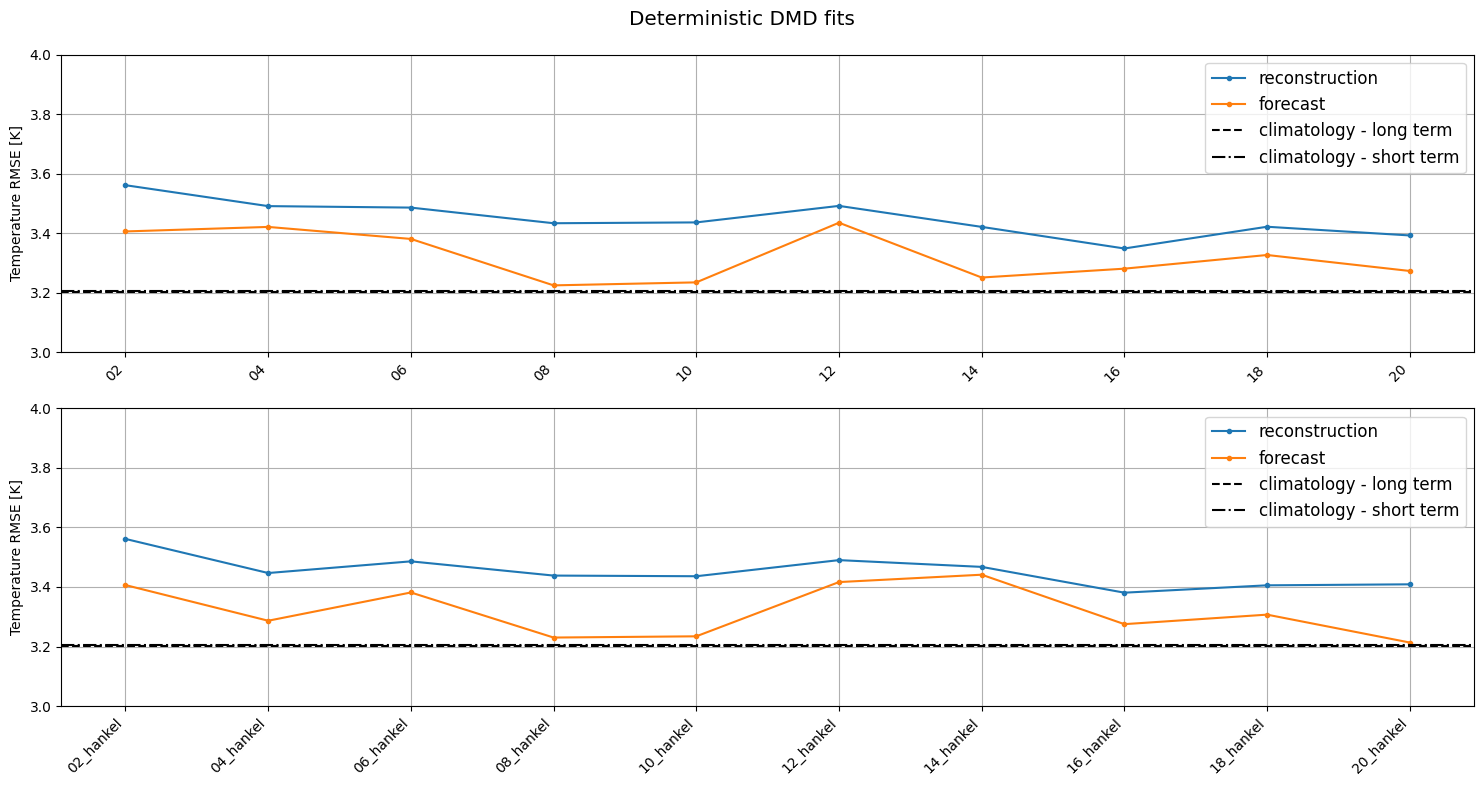

In [12]:
fig, axs = plt.subplots(2, 1, figsize=(15, 8))
axs = axs.flatten()
plt.rcParams.update({'font.size': 12})

def plot_results(axs, keys, reconstruction_vals, forecast_vals, ylim = (3, 4)):
    axs.plot(reconstruction_vals, ".-", label="reconstruction")
    axs.plot(forecast_vals, ".-", label="forecast")
    axs.set_xticks(range(len(reconstruction_vals)))
    axs.set_xticklabels(list(keys), rotation=45, ha="right")
    axs.set_ylim(ylim)
    axs.axhline(
        y=rmse_clima_long_term.mean().values,
        color='k',
        linestyle='--',
        label="climatology - long term",
    )
    axs.axhline(
        y=rmse_clima_short_term.mean().values,
        color='k',
        linestyle='-.',
        label="climatology - short term",
    )
    axs.set_ylabel("Temperature RMSE [K]")
    axs.grid()
    axs.legend()

keys = [key for key, _ in reconstruction_averages]
reconstruction_vals = [val for _, val in reconstruction_averages]
forecast_vals = [val for _, val in forecast_averages]
plot_results(axs[0], keys, reconstruction_vals, forecast_vals)

keys = [key for key, _ in reconstruction_hankel_averages]
reconstruction_vals = [val for _, val in reconstruction_hankel_averages]
forecast_vals = [val for _, val in forecast_hankel_averages]
plot_results(axs[1], keys, reconstruction_vals, forecast_vals)

fig.suptitle("Deterministic DMD fits")
fig.tight_layout()
plt.show()

The plot above suggests that a DMD model with 10 modes might be competitive with climatology, and that Hankel pre-processing does not produce a noticeable difference in improving the model accuracy in this case. The likely reason for this is that we have a long enough temporal sample (10 years in this case) to extract all relevant dynamics.

Below we plot the reconstruction and forecast RMSE for a 10 mode DMD model as a function of time, and compare against climatology computed using the same training data.

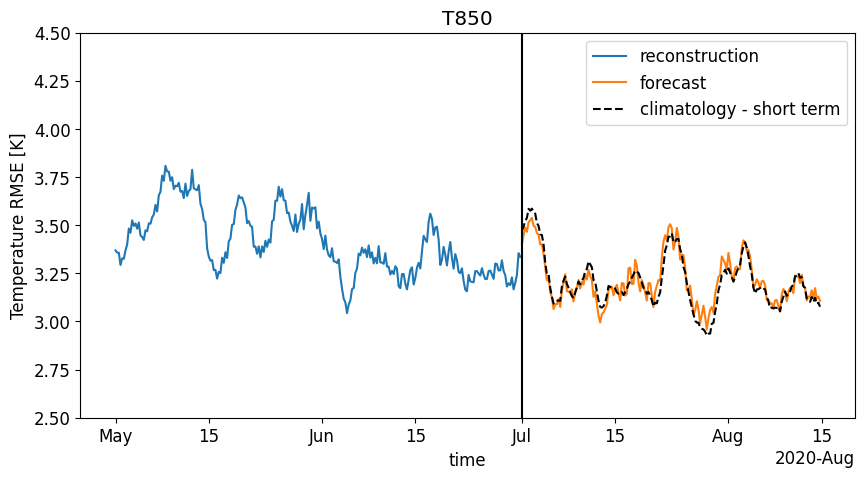

In [13]:
model = "20_hankel"
forecast_starts = "2020-07-01T00"

plt.figure(figsize=(10, 5))
reconstructions_hankel[model].plot(label="reconstruction")
forecasts_hankel[model].plot(label="forecast")
rmse_clima_short_term.plot(color="k", linestyle = "--", label="climatology - short term")
plt.axvline(pd.Timestamp(forecast_starts), color="k")
plt.ylim((2.5, 4.5))
plt.legend()
plt.ylabel("Temperature RMSE [K]")
plt.title("T850")

plt.show()

## Probabilistic DMD models

We now repeat the same process for the probabilistic DMD models, which have been obtained from ensembles of DMD fits produced using bootstrap aggregation. Note that here we are only evaluating the ensemble average DMD models. 

In [14]:
reconstruction_files = sorted(glob("metrics/probabilistic/reconstruction*"))
forecast_files = sorted(glob("metrics/probabilistic/forecast*"))

In [15]:
reconstructions = {}
reconstructions_hankel = {}
for file in reconstruction_files:
    path = Path(file)
    name = path.name.split(".")[0]
    name = name.split("rmse_")[-1]
    if "hankel" in name:
        reconstructions_hankel[name] = xr.open_dataarray(file)
    else:
        reconstructions[name] = xr.open_dataarray(file)

In [16]:
forecasts = {}
forecasts_hankel = {}
for file in forecast_files:
    path = Path(file)
    name = path.name.split(".")[0]
    name = name.split("rmse_")[-1]
    if "hankel" in name:
        forecasts_hankel[name] = xr.open_dataarray(file)
    else:
        forecasts[name] = xr.open_dataarray(file)

In [17]:
reconstruction_averages = []
reconstruction_hankel_averages = []
forecast_averages = []
forecast_hankel_averages = []

for key in reconstructions.keys():
    reconstruction_averages.append((key, reconstructions[key].mean().values))
    forecast_averages.append((key, forecasts[key].mean().values))

for key in reconstructions_hankel.keys():
    reconstruction_hankel_averages.append(
        (key, reconstructions_hankel[key].mean().values)
    )
    forecast_hankel_averages.append((key, forecasts_hankel[key].mean().values))

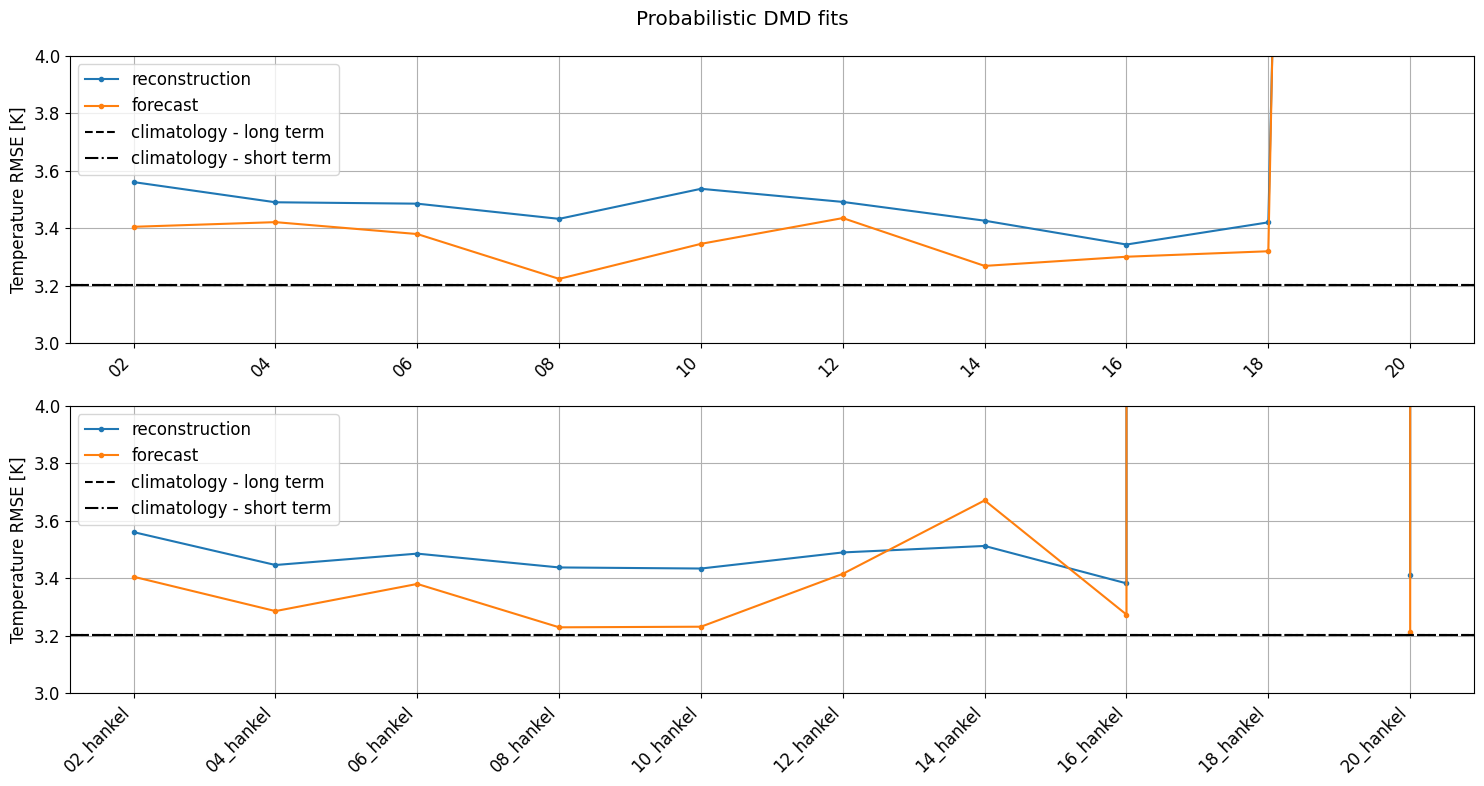

In [18]:
fig, axs = plt.subplots(2, 1, figsize=(15, 8))
axs = axs.flatten()
plt.rcParams.update({'font.size': 12})

keys = [key for key, _ in reconstruction_averages]
reconstruction_vals = [val for _, val in reconstruction_averages]
forecast_vals = [val for _, val in forecast_averages]
plot_results(axs[0], keys, reconstruction_vals, forecast_vals)

keys = [key for key, _ in reconstruction_hankel_averages]
reconstruction_vals = [val for _, val in reconstruction_hankel_averages]
forecast_vals = [val for _, val in forecast_hankel_averages]
plot_results(axs[1], keys, reconstruction_vals, forecast_vals)

fig.suptitle("Probabilistic DMD fits")
fig.tight_layout()
plt.show()

Similarly to the deterministic DMD fits, a 10 mode model without Hankel pre-processing seems to be competitive with climatology. Note that some models (e.g. 14 modes without Hankel pre-processing, or 12 modes with Hankel pre-processing) are unstable. This is because some of the ensemble members in those cases are spurious, leading to a spurious ensemble average. Bootstrap aggregation is performed by randomly sampling snapshots from the data matrix while maintaining time order, and it might be that some of the resulting matrices become ill-conditioned.

Below we plot the reconstruction and forecast RMSE for a probabilistic DMD model with 10 modes and without Hankel pre-processing, and compare against climatology.

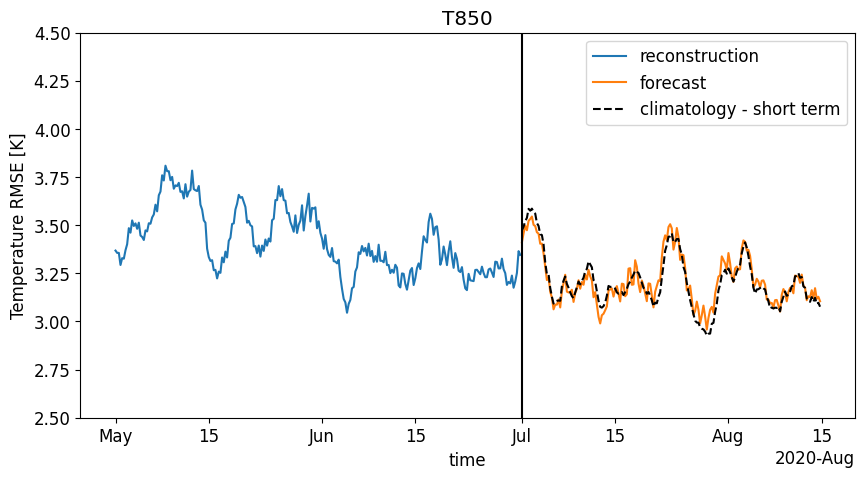

In [19]:
model = "20_hankel"
forecast_starts = "2020-07-01T00"

plt.figure(figsize=(10, 5))
reconstructions_hankel[model].plot(label="reconstruction")
forecasts_hankel[model].plot(label="forecast")
rmse_clima_short_term.plot(color="k", linestyle = "--", label="climatology - short term")
plt.axvline(pd.Timestamp(forecast_starts), color="k")
plt.ylim((2.5, 4.5))
plt.legend()
plt.ylabel("Temperature RMSE [K]")
plt.title("T850")

plt.show()